In [39]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [40]:
# Load image
image_path = "Raman_PETN_mod.png"   # replace with your image path
img = Image.open(image_path)

# Convert to grayscale
gray_img = img.convert("L")

# Convert grayscale image to NumPy array
pixel_array = np.array(gray_img)

# Display results
print("Pixel Array Shape:", pixel_array.shape)
print("Pixel Data:\n", pixel_array)

# Optional: save grayscale image
gray_img.save("grayscale_output.jpg")

Pixel Array Shape: (503, 1380)
Pixel Data:
 [[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


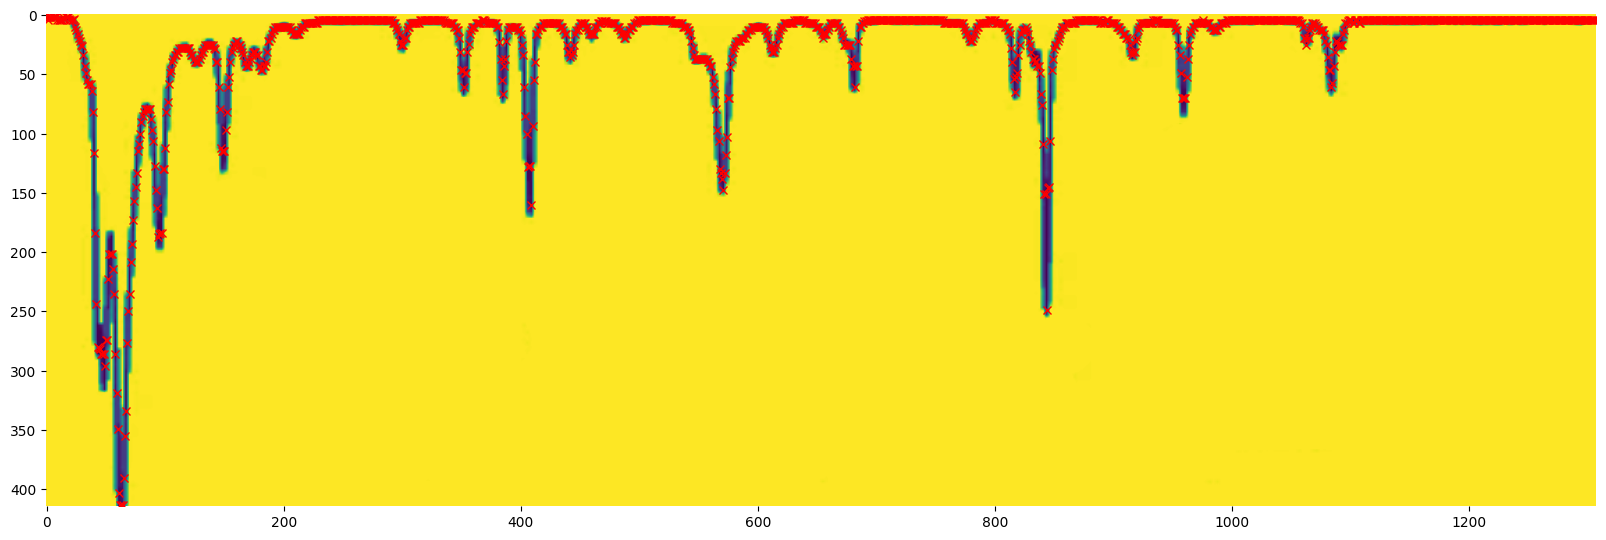

In [41]:
plt.figure(figsize=(20,10))
#x = 0 -> 2000
new_px_arr = np.flipud(pixel_array[15:430,22:1330])
#new_px_arr = np.flipud(pixel_array[15:423,350:450])
plt.imshow(new_px_arr)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

x_idx = []
y_arr_f = []

for col_idx in range(new_px_arr.shape[1]):
  if col_idx%1 == 0:
    y_min = 1000
    y_min_idx = 0
    if (col_idx > 100) & (col_idx < 200):
      y_lim = 130
    elif (col_idx > 200) & (col_idx < 800):
      y_lim = 170
    elif (col_idx > 800) & (col_idx < 900):
      y_lim = 250
    elif (col_idx > 900):
      y_lim = 80
    else:
      y_lim = -1
    y_arr = new_px_arr[:y_lim,col_idx]
    y_arr_min = np.min(y_arr)
    y_min_idx_arr = [0]
    for i,y in enumerate(y_arr):
      if y == y_arr_min:
        y_min_idx_arr.append(i)
    if np.max(y_min_idx_arr) == y_lim:
      y_val = 0
    else:
      y_val = np.max(y_min_idx_arr)
    x_idx.append(col_idx)
    y_arr_f.append(y_val)
    plt.plot(col_idx, y_val, 'rx')

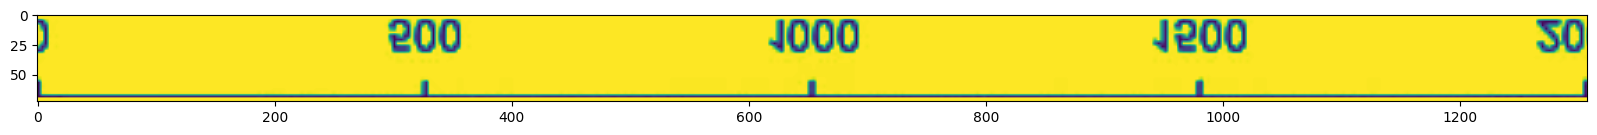

In [42]:
plt.figure(figsize=(20,10))
#x = 0 -> 2000
new_px_arr = np.flipud(pixel_array[430:,22:1330])
#new_px_arr = np.flipud(pixel_array[15:423,350:450])
plt.imshow(new_px_arr)

In [43]:
def map_range(array, a, b, c, d):
    """
    Maps values from a source range [a, b] to a target range [c, d]
    using a linear formula.
    """
    # Normalized value (0 to 1) within the source range
    normalized_array = (array - a) / (b - a)
    # Scaled and offset to the target range
    mapped_array = normalized_array * (d - c) + c
    return mapped_array

Text(0, 0.5, 'Normalized Intensity (a.u.)')

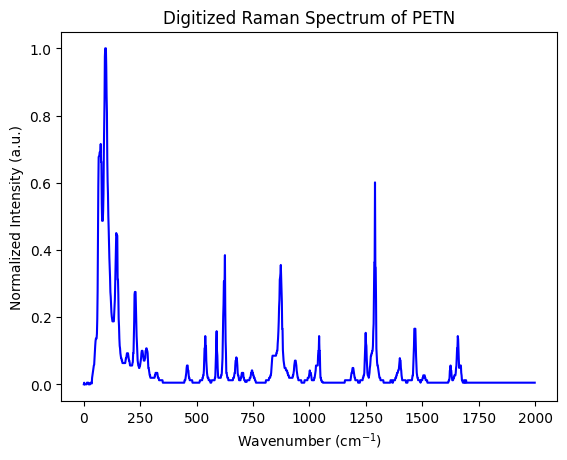

In [44]:
wn = map_range(np.array(x_idx),0,new_px_arr.shape[1],0,2000)
norm_signal = map_range(np.array(y_arr_f),np.min(np.array(y_arr_f)),np.max(np.array(y_arr_f)),0,1)
plt.plot(wn, norm_signal, 'b-')
plt.title("Digitized Raman Spectrum of PETN")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Normalized Intensity (a.u.)")

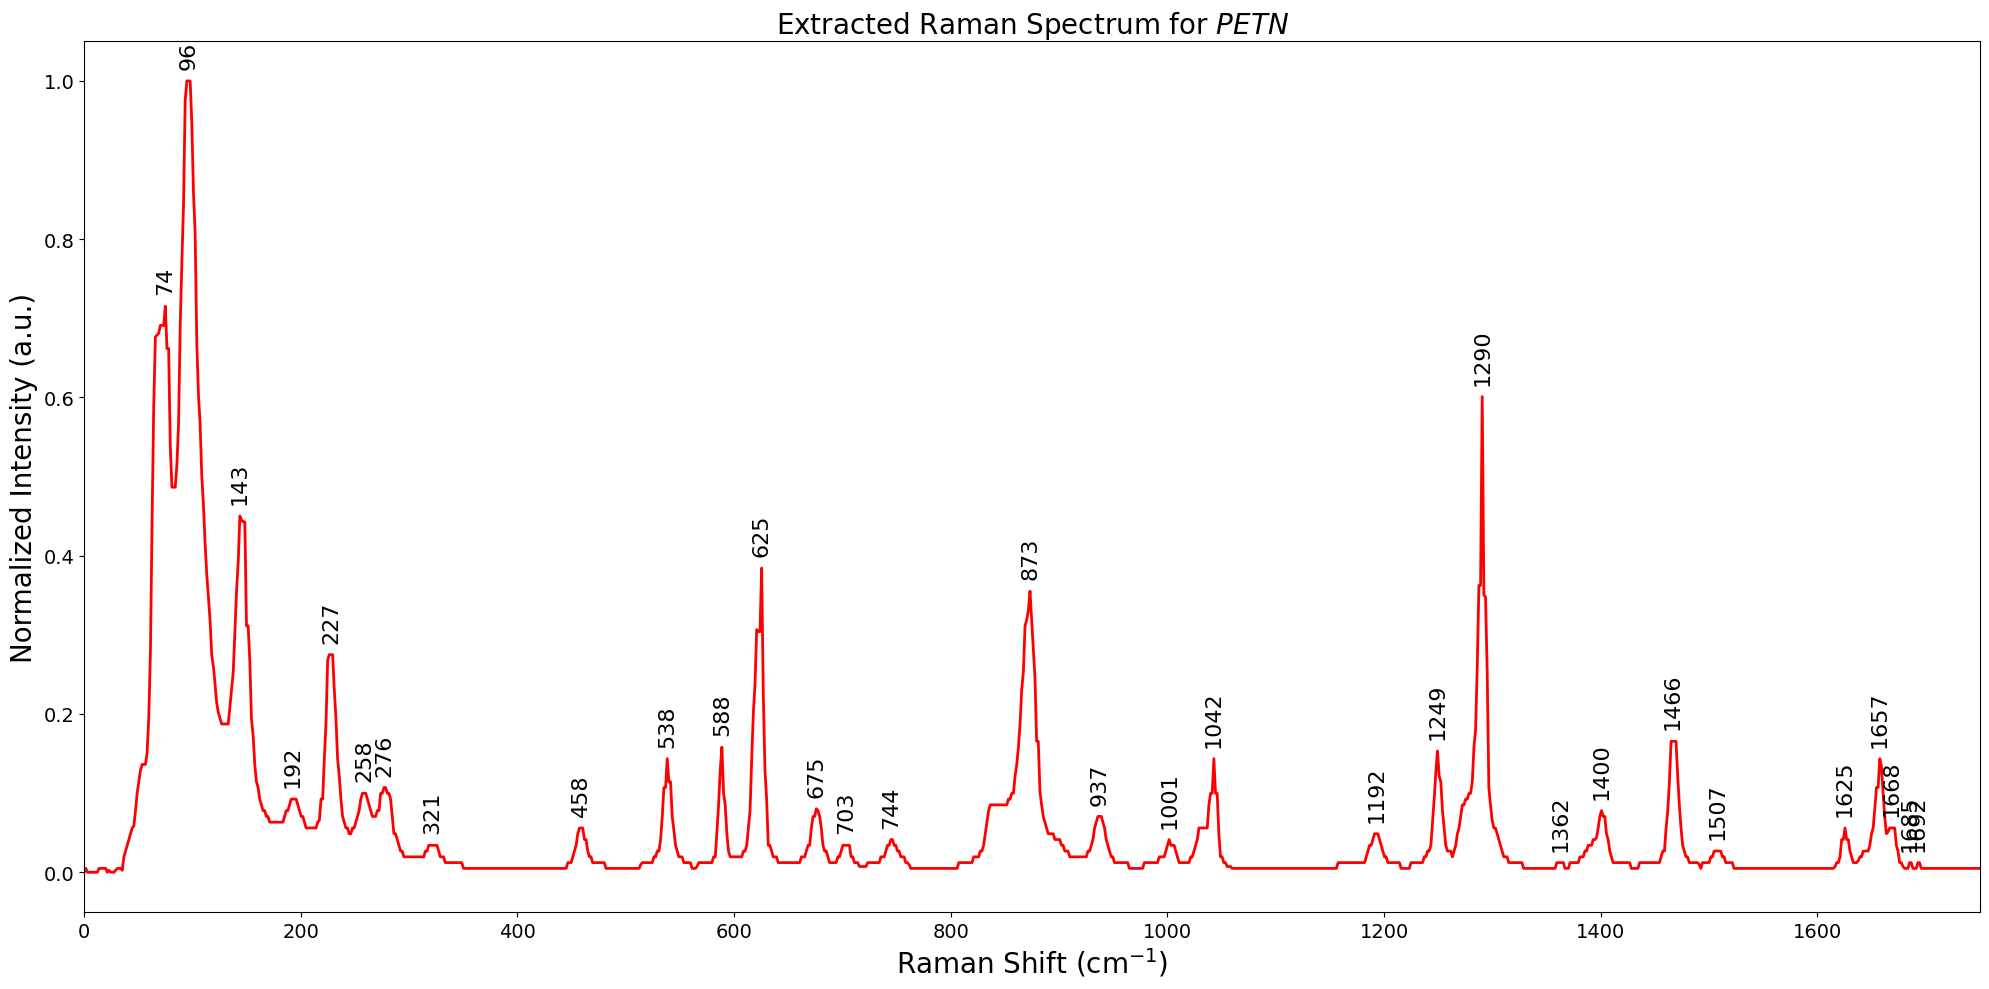

In [72]:
plt.figure(figsize=(20,10))
plt.plot(wn, norm_signal, 'r-', lw=2)

peaks, properties = find_peaks(
    norm_signal,
    height=0.01,        # minimum peak height
    distance=5,      # minimum distance between peaks
    prominence=0.005     # peak prominence
)

#lt.plot(wn[peaks], norm_signal[peaks], "kx")

for peak in peaks:
    plt.text(wn[peak], norm_signal[peak]+0.02, f"{int(wn[peak])}", ha='center', rotation=90, fontdict={'fontsize': 16})
plt.xlabel("Raman Shift (cm$^{-1}$)", fontdict={'fontsize': 20})
plt.ylabel("Normalized Intensity (a.u.)", fontdict={'fontsize': 20})
plt.title("Extracted Raman Spectrum for $PETN$", fontdict={'fontsize': 20})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim([0, 1750])
plt.tight_layout()
plt.savefig("Raman_PETN_extracted.png", dpi=300)
plt.show()